In [50]:
# 🚖 Uber Fare Prediction using Machine Learning

# Author: Harsh Gopinath Chavan

# Objective:
# Predict Uber ride fares using Linear Regression and Random Forest Regression models

# Dataset:
# Uber Fares Dataset (Kaggle)

In [51]:
# IMPORTING REQUIERD LIBRARIES 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

In [52]:
# LOAD DATASET AND EXPLORATAORY DATA ANALYSIS(EDA)

In [53]:
df = pd.read_csv("uber.csv")

print("Dataset loaded successfully.\n")

Dataset loaded successfully.



In [54]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [55]:
print(f"\nDataset Shape: {df.shape}")



Dataset Shape: (200000, 9)


In [56]:
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [57]:
print("\nStatistical Summary:")
display(df.describe())



Statistical Summary:


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [58]:
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [59]:
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Duplicate Records: 0


In [60]:
# EXPLORATAORY DATA ANALYSIS(EDA)
# The dataset is explored to understand its structure, identify missing values, detect duplicates, 
# and visualize important features before preprocessing.

Text(0.5, 0, 'Fare Amount')

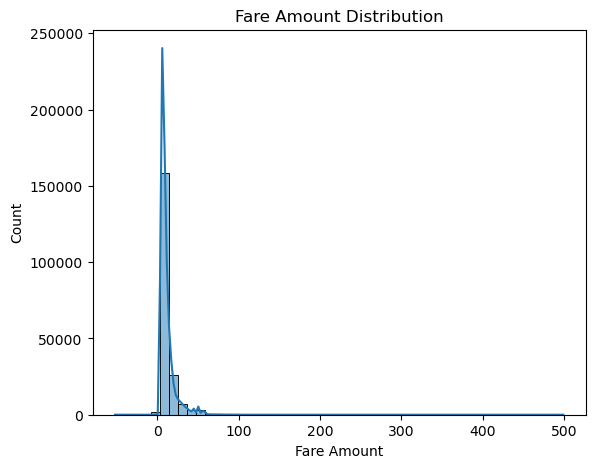

In [61]:
plt.figure(figsize=(14,5))

# Fare Amount Distribution
plt.subplot(1,2,1)
sns.histplot(df["fare_amount"], bins=50, kde=True)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")

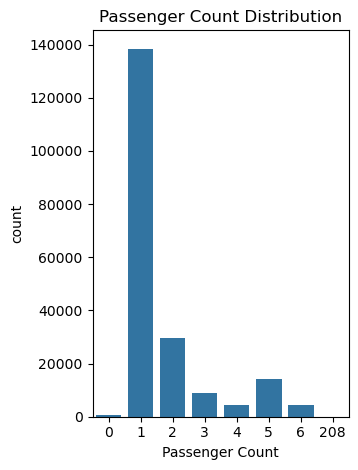

In [62]:
# Passenger Count Distribution
plt.subplot(1,2,2)
sns.countplot(x="passenger_count", data=df)
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")

plt.tight_layout()
plt.show()

In [63]:
# DATA PREPROCESSING

# The dataset is cleaned by:
# - Removing unnecessary columns
# - Handling missing values
# - Converting the datetime column
# - Extracting date and time features
# - Removing invalid coordinates, fare amounts, and passenger counts

# The cleaned dataset is then used for feature engineering and model training.

In [64]:
# Remove unnecessary columns
df.drop(columns=["Unnamed: 0", "key"], inplace=True, errors="ignore")

# Remove missing values
df.dropna(inplace=True)

# Convert pickup_datetime to datetime
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")

df.dropna(subset=["pickup_datetime"], inplace=True)

# Extract date and time features
df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["hour"] = df["pickup_datetime"].dt.hour

# Remove invalid coordinates
df = df[
    df["pickup_latitude"].between(-90, 90) &
    df["dropoff_latitude"].between(-90, 90) &
    df["pickup_longitude"].between(-180, 180) &
    df["dropoff_longitude"].between(-180, 180)
]

# Remove invalid fare and passenger count
df = df[(df["fare_amount"] > 0) & (df["passenger_count"] > 0)]

print(f"Dataset Shape after Preprocessing: {df.shape}")

display(df.head())

Dataset Shape after Preprocessing: (199257, 11)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [65]:
# FEATURE ENGINEERING
# A new feature, `distance_km`, is created using the Haversine formula to calculate the distance between pickup 
# and drop-off locations. This feature is expected to improve fare prediction.

In [66]:

# Function to calculate distance using the Haversine Formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

# Create distance feature
df["distance_km"] = df.apply(
    lambda row: haversine(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]
    ),
    axis=1
)

# Remove unnecessary columns
df.drop(
    columns=[
        "pickup_datetime",
        "pickup_latitude",
        "pickup_longitude",
        "dropoff_latitude",
        "dropoff_longitude"
    ],
    inplace=True
)

print("Feature Engineering Completed Successfully!")

display(df.head())
# Display the newly created distance feature
display(df[["fare_amount", "distance_km"]].head())

Feature Engineering Completed Successfully!


,fare_amount,passenger_count,year,month,day,hour,distance_km
0,7.5,1,2015,5,7,19,1.683323
1,7.7,1,2009,7,17,20,2.457590
2,12.9,1,2009,8,24,21,5.036377
3,5.3,3,2009,6,26,8,1.661683
4,16.0,5,2014,8,28,17,4.475450


,fare_amount,distance_km
0,7.5,1.683323
1,7.7,2.457590
2,12.9,5.036377
3,5.3,1.661683
4,16.0,4.475450


In [67]:
# OUTLIER DETECTION
# Outliers in the fare amount are detected using the IQR method and removed to improve model performance.

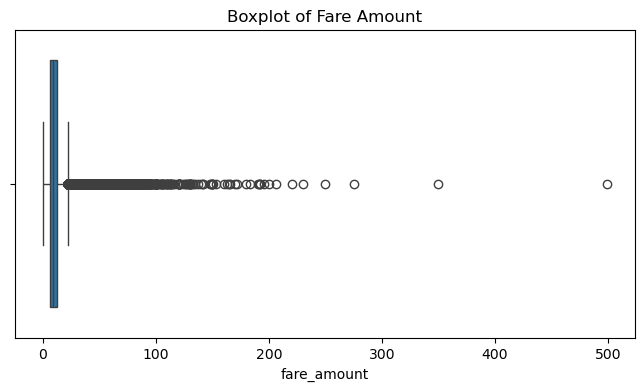

Before Removing Outliers : (199257, 7)
After Removing Outliers  : (182137, 7)


In [68]:
# Boxplot before removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare_amount"])
plt.title("Boxplot of Fare Amount")
plt.show()

# Store original shape
before_shape = df.shape

# Calculate IQR
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df = df[
    (df["fare_amount"] >= Q1 - 1.5 * IQR) &
    (df["fare_amount"] <= Q3 + 1.5 * IQR)
]

df.reset_index(drop=True, inplace=True)

# Compare dataset size
print("Before Removing Outliers :", before_shape)
print("After Removing Outliers  :", df.shape)

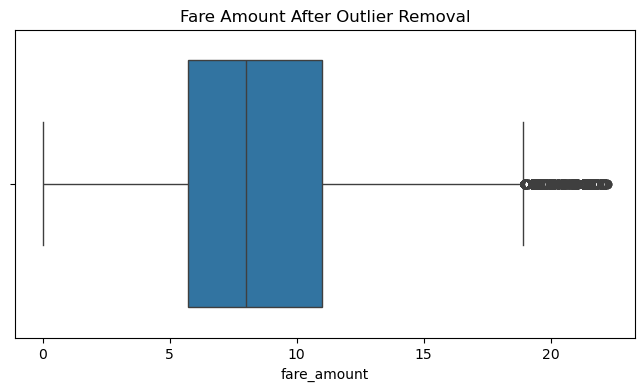

In [69]:
# Boxplot after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount After Outlier Removal")
plt.show()

In [70]:
# CORRELATION ANALYSIS

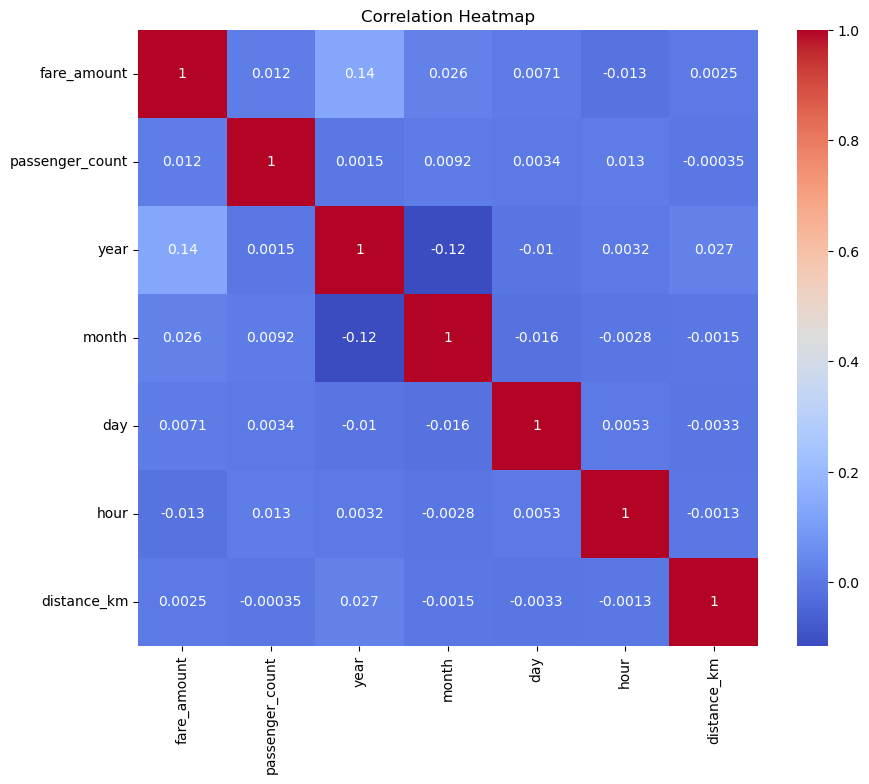

In [71]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [72]:
# TRAIN-TEST-SPLIT

In [73]:
X = df.drop("fare_amount", axis=1)
y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
# LINEAR REGRESSION 
# A Linear Regression model is trained to predict Uber fares and evaluated using R² Score, RMSE, and MAE.

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Some of the predictions are: ",lr_pred)

print("\nLinear Regression model trained successfully.")

Some of the predictions are:  [8.51706622 8.31298499 8.5430191  ... 8.89225342 8.34346937 8.00147873]

Linear Regression model trained successfully.


In [76]:
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"R² Score : {lr_r2:.4f}")
print(f"RMSE     : {lr_rmse:.4f}")
print(f"MAE      : {lr_mae:.4f}")

Linear Regression Performance
-----------------------------------
R² Score : 0.0194
RMSE     : 4.0966
MAE      : 3.2422


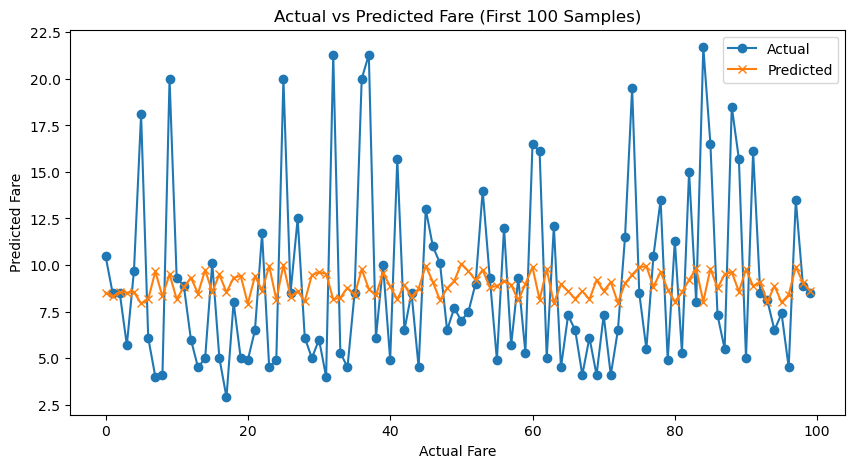

In [77]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual", marker='o')
plt.plot(lr_pred[:100], label="Predicted", marker='x')

plt.title("Actual vs Predicted Fare (First 100 Samples)")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.legend()

plt.show()

In [78]:
# RANDOM FOREST REGRESSION
# A Random Forest Regression model is trained and evaluated. 
# Its performance is later compared with Linear Regression.

In [79]:
rf_model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs= -1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Some of the predictions are: ", rf_pred)
print("\nRandom Forest model trained successfully.")

Some of the predictions are:  [ 8.41 10.58  6.6  ...  7.2   5.38  6.6 ]

Random Forest model trained successfully.


In [80]:
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Performance")
print("-" * 35)
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"MAE      : {rf_mae:.4f}")

Random Forest Performance
-----------------------------------
R² Score : 0.6959
RMSE     : 2.2815
MAE      : 1.6223


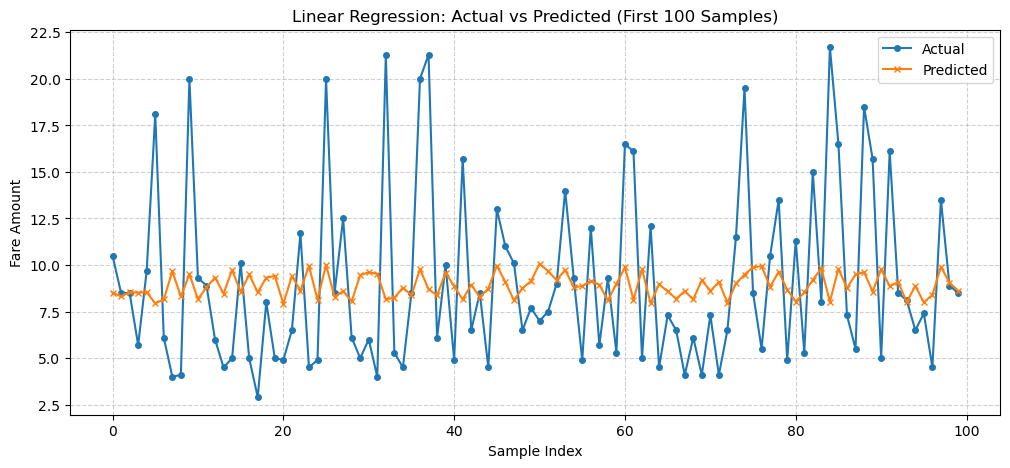

In [81]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual",
    marker='o',
    markersize=4
)

plt.plot(
    lr_pred[:100],
    label="Predicted",
    marker='x',
    markersize=4
)

plt.title("Linear Regression: Actual vs Predicted (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [82]:
# MODEL EVALUATION AND COMPARISION
# The performance of both models is compared using R² Score, RMSE, and MAE to identify the better-performing model.

,Model,R² Score,RMSE,MAE
0,Linear Regression,0.0194,4.0966,3.2422
1,Random Forest,0.6959,2.2815,1.6223


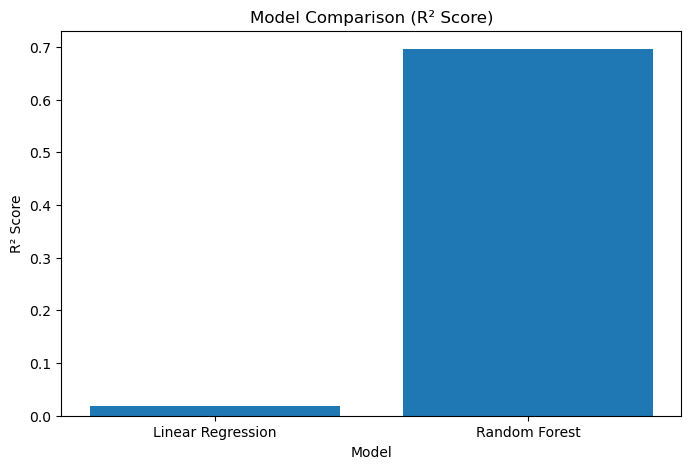

In [83]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [lr_r2, rf_r2],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae]
})

results = results.round(4)

display(results)

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

Text(0, 0.5, 'Features')

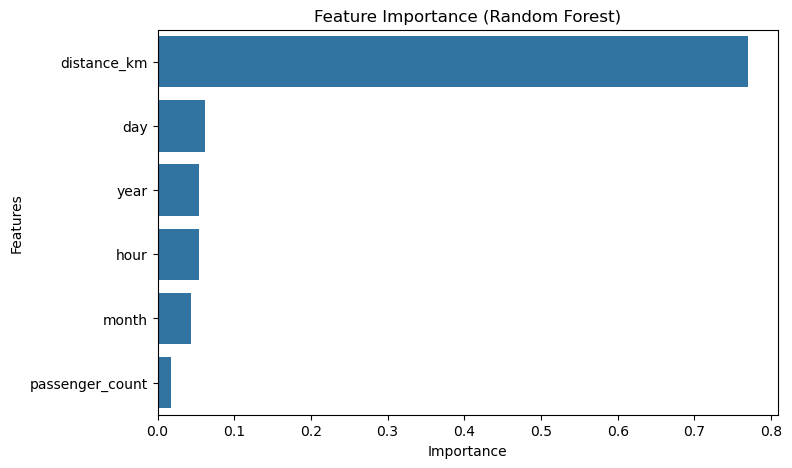

In [84]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")


In [85]:
# BEST MODEL

In [86]:
best_model = results.loc[results["R² Score"].idxmax(), "Model"]
print(f"Best Performing Model: {best_model}")

Best Performing Model: Random Forest


In [87]:
# ✅ Conclusion

# - The dataset was successfully cleaned and preprocessed.
# - Haversine distance was created as a new feature.
# - Outliers were removed using the IQR method.
# - Linear Regression and Random Forest Regression models were trained and evaluated.
# - Random Forest achieved better performance with a higher R² Score and lower RMSE and MAE.
# - Therefore, Random Forest is the preferred model for Uber fare prediction.